In [1]:
from google.colab import files
uploaded = files.upload()

Saving gaming_addiction.csv to gaming_addiction.csv


STEP 1 : Loading Dataset
     user_id  age  gender      country occupation  income_level  years_gaming  \
0  USR000001   21    Male        India   Employed        Middle             9   
1  USR000002   25    Male        India   Employed  Lower-Middle            13   
2  USR000003   26    Male       Brazil   Employed        Middle            14   
3  USR000004   22    Male  South Korea   Employed  Upper-Middle            10   
4  USR000005   17  Female        India    Student        Middle             5   

  preferred_genre   platform  device_type  ... absenteeism_days  \
0         Sandbox         PC       Laptop  ...                7   
1             RPG     Mobile        Mixed  ...                6   
2             RPG  PC+Mobile  High-end PC  ...                7   
3        Strategy  PC+Mobile       Mobile  ...                8   
4        Strategy         PC       Laptop  ...                6   

   internet_speed_mbps  screen_time_total_hours   behavioral_cluster  \
0            

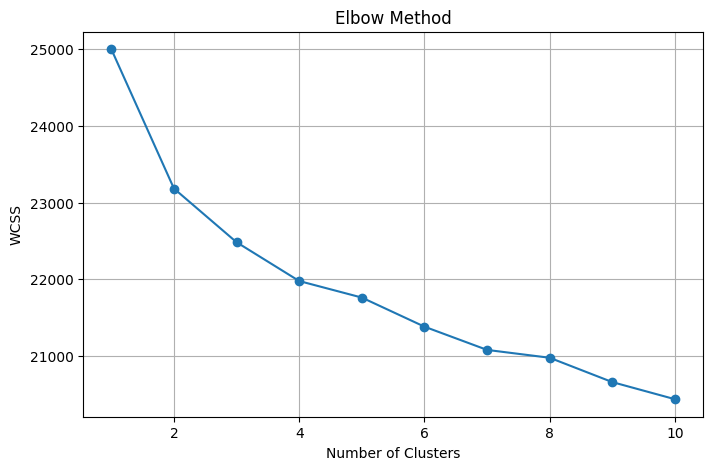

 Choose the point where the graph bends. That value is usually the optimal number of clusters. For this example we use K = 3. 

Cluster Counts
Cluster
1    118
2     99
0     33
Name: count, dtype: int64

Silhouette Score = 0.065
Poor clustering

Reducing dimensions using PCA...


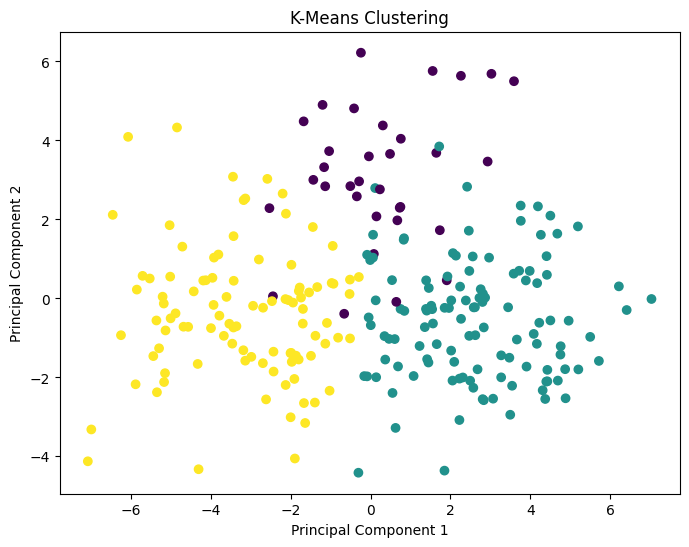

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer # Import SimpleImputer

# ==========================================================
# STEP 1 : LOAD DATASET
# ==========================================================

print("="*60)
print("STEP 1 : Loading Dataset")
print("="*60)

df = pd.read_csv("gaming_addiction.csv")

print(df.head())
print("\nShape:", df.shape)

# ==========================================================
# STEP 2 : REMOVE IDENTIFIER COLUMN
# ==========================================================

if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])

# ==========================================================
# STEP 3 : CONVERT CATEGORICAL DATA
# ==========================================================

print("\nConverting categorical columns...")

categorical_cols = df.select_dtypes(include=["object"]).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Dataset Shape After Encoding:", df.shape)

# ==========================================================
# STEP 4 : SELECT FEATURES
# ==========================================================

print("\nPreparing features...")

X = df.copy()

# ==========================================================
# STEP 5 : IMPUTE MISSING VALUES
# ==========================================================

print("Imputing missing values...")

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Convert back to DataFrame to preserve column names if needed for inspection,
# but StandardScaler can directly take numpy array.
X = pd.DataFrame(X_imputed, columns=X.columns)

# ==========================================================
# STEP 6 : FEATURE SCALING
# ==========================================================

print("Scaling data...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# STEP 7 : ELBOW METHOD
# ==========================================================

print("\nFinding optimal K...")

wcss = []

for k in range(1,11):
    model = KMeans(n_clusters=k,
                   random_state=42,
                   n_init=10)

    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

print(""" Choose the point where the graph bends. That value is usually the optimal number of clusters. For this example we use K = 3. """)

# ==========================================================
# STEP 8 : TRAIN KMEANS
# ==========================================================

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\nCluster Counts")
print(df["Cluster"].value_counts())

# ==========================================================
# STEP 9 : EVALUATION
# ==========================================================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score =", round(score,3))

if score > 0.7:
    print("Excellent clustering")
elif score > 0.5:
    print("Good clustering")
elif score > 0.3:
    print("Average clustering")
else:
    print("Poor clustering")

# ==========================================================
# STEP 10 : PCA VISUALIZATION
# ==========================================================

print("\nReducing dimensions using PCA...")

pca = PCA(n_components=2)

reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()